# Human GT → V2 Fabrication Correction

For every feature coded **`status_ai == 3`** (fabrication) in the human-validated sheet  
`merged_llm_summary_validation_datasheet_identified.xlsx`, determine whether the **V2 prompt corrected it**.

Ground truth source: human annotation (not LLM judge) for V1.  
V2 verdict: GPT-4o LLM judge reading the **full V2 JSON** (not just extracted feature).

In [1]:
import os, sys, json, re, time
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

PROJECT_ROOT = Path(os.getenv('PROJECT_ROOT',
    r'C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center'
    r'\Documents\GitHub\llm_summarization_br_ca'))
DATA_PRIVATE = Path(os.getenv('DATA_PRIVATE_DIR', r'C:\Users\jamesr4\loc\data_private'))

sys.path.insert(0, str(PROJECT_ROOT / 'src' / 'llm_eval_by_llm'))
from deepeval_multi_model_pipeline import call_llm

OCR_CACHE    = DATA_PRIVATE / 'ocr_cache'
MAPPING_CSV  = DATA_PRIVATE / 'breast_bot_deidentified' / 'case_id_mapping.csv'
GT_XLSX      = DATA_PRIVATE / 'raw' / 'merged_llm_summary_validation_datasheet_identified.xlsx'
V2_CSV       = DATA_PRIVATE / 'raw' / 'v2_summary_paths.csv'
DEEPEVAL_OUT = PROJECT_ROOT / 'data' / 'processed' / 'deepeval_runs' / 'fab_v1_v2'
REPORTS_DIR  = PROJECT_ROOT / 'reports'
CACHE_FILE   = PROJECT_ROOT / 'fabrication_analysis' / 'cache' / 'llm_judge_cache.json'

for d in [DEEPEVAL_OUT, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('Setup OK')
print(f'GT_XLSX exists: {GT_XLSX.exists()}')

Setup OK
GT_XLSX exists: True


In [2]:
# Load all (MRN, feature) pairs where status_ai == 3 in the identified validation sheet
val_df = pd.read_excel(GT_XLSX, sheet_name='all_cases')
val_df['mrn'] = pd.to_numeric(val_df['mrn'], errors='coerce')
val_df = val_df.dropna(subset=['mrn'])
val_df['mrn'] = val_df['mrn'].astype(int)

FAB_MRNS = [39089057, 38138814, 39100822, 39091629, 39111396,
            39095007, 39094834, 39092180, 39089385, 39102467,
            39106459, 39103258, 39100321, 38307961]

ai_cols = [c for c in val_df.columns if c.endswith('_status_ai')]
src_col_map = {c: c.replace('_status_ai', '_status_source') for c in ai_cols}

fab3_pairs = []
for mrn in FAB_MRNS:
    row = val_df[val_df['mrn'] == mrn]
    if row.empty:
        print(f'WARN: MRN {mrn} not found in validation sheet')
        continue
    row = row.iloc[0]
    for ai_col in ai_cols:
        val = pd.to_numeric(row[ai_col], errors='coerce')
        if val == 3:
            feat = ai_col.replace('_status_ai', '')
            src_col = src_col_map[ai_col]
            src_val = pd.to_numeric(row.get(src_col, None), errors='coerce')
            fab3_pairs.append({
                'mrn':            mrn,
                'feature':        feat,
                'source_present': int(src_val) if pd.notna(src_val) else None,
                'v1_human_code':  3,
            })

fab3_df = pd.DataFrame(fab3_pairs)
print(f'Human-confirmed V1 fabrications: {len(fab3_df)} (case, feature) pairs')
print(fab3_df.to_string(index=False))

Human-confirmed V1 fabrications: 14 (case, feature) pairs
     mrn                           feature  source_present  v1_human_code
39089057 invasive_component_size_pathology               1              3
38138814              histologic_diagnosis               1              3
39100822                       lesion_size               1              3
39091629                          receptor               1              3
39111396                       lesion_size               1              3
39095007                       lesion_size               1              3
39094834 invasive_component_size_pathology               1              3
39092180                          receptor               1              3
39089385              chronology_preserved               1              3
39102467                     biopsy_method               1              3
39106459             workup_recommendation               1              3
39103258                            extent            

In [3]:
# Build OCR text per MRN from cache
_SURGEON_MAP = {
    'el tamer': 'el tamer', 'el-tamer': 'el tamer',
    'sacchini': 'sacchini', 'giannakou': 'giannakou',
    'montagna': 'montag', 'montag': 'montag', 'lisa allen': 'allen',
}
def _norm(s):
    return _SURGEON_MAP.get(str(s).strip().lower(), str(s).strip().lower())

mapping = pd.read_csv(MAPPING_CSV)
mapping['surgeon_norm'] = mapping['surgeon'].apply(_norm)

ocr_by_mrn = {}
cf_by_mrn  = {}
for mrn in FAB_MRNS:
    # Get case folders for this MRN via mapping
    case_rows = mapping[mapping['mrn'] == mrn] if 'mrn' in mapping.columns else pd.DataFrame()
    if case_rows.empty:
        # fallback: match via val_df initials
        vrow = val_df[val_df['mrn'] == mrn].iloc[0]
        initials = str(vrow.get('patient_initials', '')).upper()
        surgeon  = str(vrow.get('surgeon', '')).split(',')[0].strip()
        snorm    = _norm(surgeon)
        mapping['folder_initials'] = mapping['case_folder'].str.split('_').str[1].str.upper()
        case_rows = mapping[(mapping['surgeon_norm'] == snorm) &
                            (mapping['folder_initials'] == initials)]

    texts = []
    cf = ''
    for _, d in case_rows.iterrows():
        cf = str(d.get('case_folder', ''))
        cache = OCR_CACHE / f"{d['case_id']}.txt"
        if cache.exists():
            texts.append(f"[{d['original_filename']}]\n"
                         + cache.read_text(encoding='utf-8', errors='ignore'))
    ocr_by_mrn[mrn] = '\n\n'.join(texts)
    cf_by_mrn[mrn]  = cf
    print(f'  MRN {mrn} ({cf}): {len(texts)} docs, {len(ocr_by_mrn[mrn]):,} chars')

print('OCR loading done')

  MRN 39089057 (GM_XM_INV): 7 docs, 29,809 chars
  MRN 38138814 (DC_BF_invasive): 5 docs, 29,425 chars
  MRN 39100822 (LK_SW_INV): 6 docs, 26,004 chars
  MRN 39091629 (AT_RW_INV): 5 docs, 28,982 chars
  MRN 39111396 (MET_KS): 4 docs, 16,361 chars
  MRN 39095007 (AH_UD_INV): 8 docs, 39,172 chars
  MRN 39094834 (ML_WY_INV): 8 docs, 34,604 chars
  MRN 39092180 (GM_DR_INV): 5 docs, 151,328 chars
  MRN 39089385 (KP_MM_INV): 4 docs, 27,186 chars
  MRN 39102467 (GP_MC_INV): 10 docs, 41,181 chars
  MRN 39106459 (MET_MW): 6 docs, 24,889 chars
  MRN 39103258 (MET_MM): 5 docs, 27,109 chars
  MRN 39100321 (MET_DM): 6 docs, 52,055 chars


  MRN 38307961 (TM_FS_DCIS): 5 docs, 22,485 chars
OCR loading done


In [4]:
# Load V2 summaries and flatten full JSON to text
v2_paths = pd.read_csv(V2_CSV)

def flatten_json(obj, prefix=''):
    """Recursively flatten nested JSON into key: value lines."""
    lines = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            full_key = f'{prefix}.{k}' if prefix else k
            lines.extend(flatten_json(v, full_key))
    elif isinstance(obj, list):
        for i, item in enumerate(obj):
            lines.extend(flatten_json(item, f'{prefix}[{i}]'))
    else:
        lines.append(f'{prefix}: {obj}')
    return lines

def load_v2_full_text(path_str):
    p = Path(path_str)
    if not p.exists():
        return ''
    raw = p.read_text(encoding='utf-8', errors='ignore')
    raw = re.sub(r'^```[a-z]*\n?', '', raw.strip(), flags=re.MULTILINE)
    raw = re.sub(r'```$', '', raw.strip())
    try:
        parsed = json.loads(raw)
        return '\n'.join(flatten_json(parsed))
    except Exception:
        return raw

v2_text_by_mrn = {}
for mrn in FAB_MRNS:
    row = v2_paths[v2_paths['mrn'] == mrn]
    if row.empty:
        v2_text_by_mrn[mrn] = ''
        print(f'  MRN {mrn}: no V2 path')
    else:
        txt = load_v2_full_text(row.iloc[0]['summary_path'])
        v2_text_by_mrn[mrn] = txt
        print(f'  MRN {mrn}: {len(txt):,} chars of V2 text')

print('V2 loading done')

  MRN 39089057: 10,938 chars of V2 text
  MRN 38138814: 4,017 chars of V2 text
  MRN 39100822: 10,434 chars of V2 text
  MRN 39091629: 9,651 chars of V2 text
  MRN 39111396: 12,182 chars of V2 text
  MRN 39095007: 4,604 chars of V2 text
  MRN 39094834: 5,004 chars of V2 text
  MRN 39092180: 3,594 chars of V2 text
  MRN 39089385: 13,310 chars of V2 text
  MRN 39102467: 6,626 chars of V2 text
  MRN 39106459: 11,969 chars of V2 text
  MRN 39103258: 8,326 chars of V2 text
  MRN 39100321: 4,709 chars of V2 text
  MRN 38307961: 4,255 chars of V2 text
V2 loading done


In [5]:
# LLM judge: for each human-confirmed V1 fabrication, assess the V2 summary
JUDGE_SYSTEM = """You are a clinical data quality auditor for breast oncology.
A human reviewer has confirmed that the V1 AI summary fabricated a specific clinical feature
(the summary reported information that was NOT supported by the source documents).

Your task: evaluate whether the V2 AI summary has CORRECTED this fabrication.

Assign ONE code:
  1  = CORRECT   — V2 accurately reports the feature based on source documents
  2  = OMISSION  — V2 omits this feature entirely (not fabricated, but not reported)
  3  = FABRICATION — V2 still fabricates or misreports this feature
  "N/A" = feature is absent from source AND V2 correctly does not report it

Respond ONLY with valid JSON: {"v2_code": <1|2|3|"N/A">, "confidence": 0.0-1.0, "reasoning": "..."}"""

FEAT_DISPLAY = {
    'lesion_size':                       'Lesion Size',
    'laterality':                        'Lesion Laterality',
    'lesion_location':                   'Lesion Location',
    'calcifications_asymmetry':          'Calcifications / Asymmetry',
    'additional_enhancement_mri':        'Additional Enhancement (MRI)',
    'extent':                            'Extent',
    'accurate_clip_placement':           'Accurate Clip Placement',
    'workup_recommendation':             'Workup Recommendation',
    'Lymph node':                        'Lymph Node',
    'lymph_node':                        'Lymph Node',
    'chronology_preserved':              'Chronology Preserved',
    'biopsy_method':                     'Biopsy Method',
    'invasive_component_size_pathology': 'Invasive Component Size (Pathology)',
    'histologic_diagnosis':              'Histologic Diagnosis',
    'receptor':                          'Receptor Status',
    'receptor_status':                   'Receptor Status',
}

judge_cache = json.loads(CACHE_FILE.read_text()) if CACHE_FILE.exists() else {}

results = []
for _, pair in fab3_df.iterrows():
    mrn     = pair['mrn']
    feat    = pair['feature']
    display = FEAT_DISPLAY.get(feat, feat)
    src_int = pair['source_present']
    ocr     = ocr_by_mrn.get(mrn, '')
    v2_txt  = v2_text_by_mrn.get(mrn, '')
    cf      = cf_by_mrn.get(mrn, '')

    cache_key = f'human_gt_v2_{mrn}_{feat}'
    if cache_key in judge_cache:
        result = judge_cache[cache_key]
        print(f'  [cache] MRN {mrn} | {display}: {result.get("v2_code")}')
    else:
        user_msg = f"""CONFIRMED V1 FABRICATION — Clinical Element: {display}
Source present in documents: {src_int} (1=yes)

SOURCE DOCUMENT TEXT (first 3000 chars):
---
{ocr[:3000]}
---

V2 STRUCTURED SUMMARY (full flattened JSON):
---
{v2_txt[:4000]}
---

Human reviewers confirmed V1 fabricated '{display}'. Does V2 correct this?"""

        try:
            raw = call_llm('gpt-4o', JUDGE_SYSTEM, user_msg, temperature=0.0, max_tokens=300)
            raw = re.sub(r'^```[a-z]*\n?', '', raw.strip(), flags=re.MULTILINE)
            raw = re.sub(r'```$', '', raw.strip())
            result = json.loads(raw)
        except Exception as e:
            result = {'v2_code': None, 'confidence': 0.0, 'reasoning': str(e)}

        judge_cache[cache_key] = result
        CACHE_FILE.write_text(json.dumps(judge_cache, indent=2))
        print(f'  MRN {mrn} ({cf}) | {display}: {result.get("v2_code")}  '
              f'[conf={result.get("confidence", 0):.2f}]', flush=True)
        time.sleep(0.5)

    v2_code = result.get('v2_code')
    results.append({
        'mrn':             mrn,
        'case_folder':     cf_by_mrn.get(mrn, ''),
        'feature':         feat,
        'feature_display': display,
        'source_present':  src_int,
        'v1_human_code':   3,
        'v2_llm_code':     v2_code,
        'v2_confidence':   result.get('confidence', 0.0),
        'v2_reasoning':    result.get('reasoning', ''),
        'corrected':       str(v2_code) in ('1', '2', 'N/A'),  # not fabricated in V2
        'v2_correct':      str(v2_code) == '1',
        'v2_omission':     str(v2_code) == '2',
        'v2_fabrication':  str(v2_code) == '3',
    })

res_df = pd.DataFrame(results)
res_df.to_csv(DEEPEVAL_OUT / 'human_gt_v2_correction.csv', index=False)

n_total   = len(res_df)
n_correct = int(res_df['v2_correct'].sum())
n_omit    = int(res_df['v2_omission'].sum())
n_v2fab   = int(res_df['v2_fabrication'].sum())
n_corrected = int(res_df['corrected'].sum())  # not fabrication in V2

print(f'\nHuman-confirmed V1 fabrications: {n_total}')
print(f'  V2 CORRECT (code 1)     : {n_correct}/{n_total}')
print(f'  V2 OMISSION (code 2)    : {n_omit}/{n_total}')
print(f'  V2 FABRICATION (code 3) : {n_v2fab}/{n_total}')
print(f'  Not fabricated in V2    : {n_corrected}/{n_total} ({100*n_corrected/max(n_total,1):.0f}%)')
print()
print(res_df[['mrn','case_folder','feature_display',
              'v1_human_code','v2_llm_code','corrected']].to_string(index=False))

21:29:29  INFO      HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  MRN 39089057 (GM_XM_INV) | Invasive Component Size (Pathology): 3  [conf=0.90]


21:29:31  INFO      HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  MRN 38138814 (DC_BF_invasive) | Histologic Diagnosis: 2  [conf=0.90]


21:29:33  INFO      HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

21:29:51  INFO      HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  MRN 39100321 (MET_DM) | Workup Recommendation: 1  [conf=0.90]


21:29:53  INFO      HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  MRN 38307961 (TM_FS_DCIS) | Lesion Size: 3  [conf=0.90]



Human-confirmed V1 fabrications: 14
  V2 CORRECT (code 1)     : 6/14
  V2 OMISSION (code 2)    : 5/14
  V2 FABRICATION (code 3) : 2/14
  Not fabricated in V2    : 12/14 (86%)

     mrn    case_folder                     feature_display  v1_human_code v2_llm_code  corrected
39089057      GM_XM_INV Invasive Component Size (Pathology)              3           3      False
38138814 DC_BF_invasive                Histologic Diagnosis              3           2       True
39100822      LK_SW_INV                         Lesion Size              3           1       True
39091629      AT_RW_INV                     Receptor Status              3         N/A       True
39111396         MET_KS                         Lesion Size              3           1       True
39095007      AH_UD_INV                         Lesion Size              3           1       True
39094834      ML_WY_INV Invasive Component Size (Pathology)              3           1       True
39092180      GM_DR_INV                

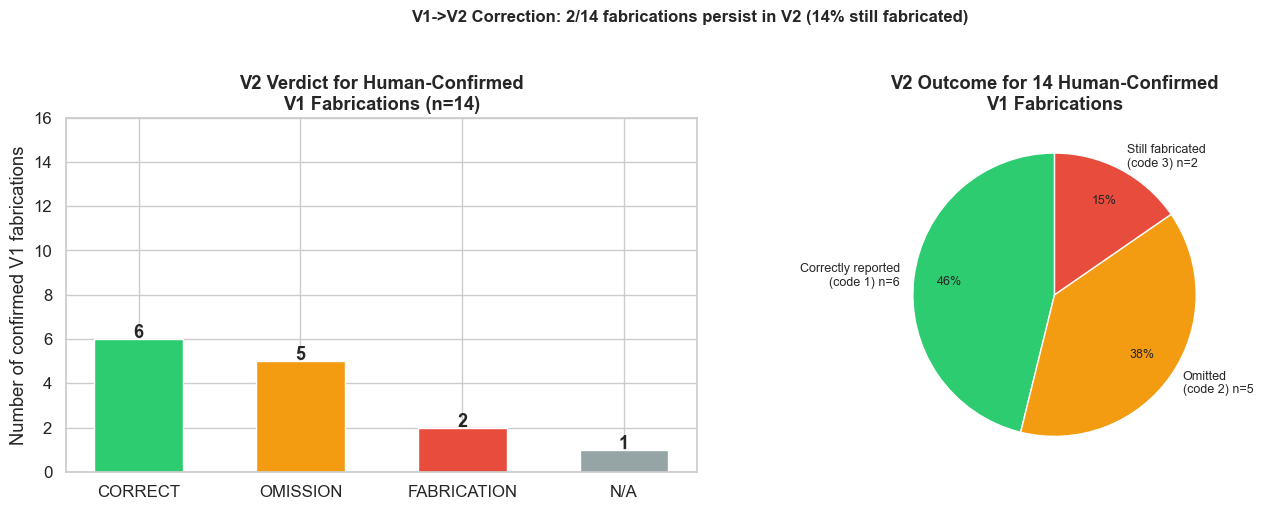

Saved: C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\reports\fab_human_gt_v2_verdict.png


In [6]:
# --- Figure 1: Stacked bar — V2 verdict breakdown + overall rate ---
CODE_COLORS = {'CORRECT': '#2ecc71', 'OMISSION': '#f39c12',
               'FABRICATION': '#e74c3c', 'N/A': '#95a5a6', 'Unknown': '#bdc3c7'}

def code_label(c):
    m = {1: 'CORRECT', 2: 'OMISSION', 3: 'FABRICATION', 'N/A': 'N/A', None: 'Unknown'}
    try:
        return m.get(int(c), m.get(c, str(c)))
    except (TypeError, ValueError):
        return m.get(c, str(c))

res_df['v2_label'] = res_df['v2_llm_code'].apply(code_label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall verdict breakdown (bar)
ax = axes[0]
order = ['CORRECT', 'OMISSION', 'FABRICATION', 'N/A', 'Unknown']
counts = res_df['v2_label'].value_counts().reindex(order, fill_value=0)
bars = ax.bar(
    [l for l in order if counts[l] > 0],
    [counts[l] for l in order if counts[l] > 0],
    color=[CODE_COLORS[l] for l in order if counts[l] > 0],
    edgecolor='white', width=0.55,
)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05,
            str(int(h)), ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(0, n_total + 2)
ax.set_ylabel('Number of confirmed V1 fabrications')
ax.set_title('V2 Verdict for Human-Confirmed\nV1 Fabrications (n=14)', fontweight='bold')

# Right: pie — corrected vs still fabricated
ax = axes[1]
pie_vals   = [n_correct, n_omit, n_v2fab]
pie_labels = [f'Correctly reported\n(code 1) n={n_correct}',
              f'Omitted\n(code 2) n={n_omit}',
              f'Still fabricated\n(code 3) n={n_v2fab}']
pie_colors = ['#2ecc71', '#f39c12', '#e74c3c']
pie_vals_nz   = [(v, l, c) for v, l, c in zip(pie_vals, pie_labels, pie_colors) if v > 0]
ax.pie(
    [x[0] for x in pie_vals_nz],
    labels=[x[1] for x in pie_vals_nz],
    colors=[x[2] for x in pie_vals_nz],
    autopct='%1.0f%%', startangle=90,
    textprops={'fontsize': 9}, pctdistance=0.75,
)
ax.set_title(f'V2 Outcome for {n_total} Human-Confirmed\nV1 Fabrications', fontweight='bold')

plt.suptitle(
    f'V1->V2 Correction: {n_v2fab}/{n_total} fabrications persist in V2 '
    f'({100*n_v2fab/max(n_total,1):.0f}% still fabricated)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
p1 = REPORTS_DIR / 'fab_human_gt_v2_verdict.png'
plt.savefig(p1, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p1}')

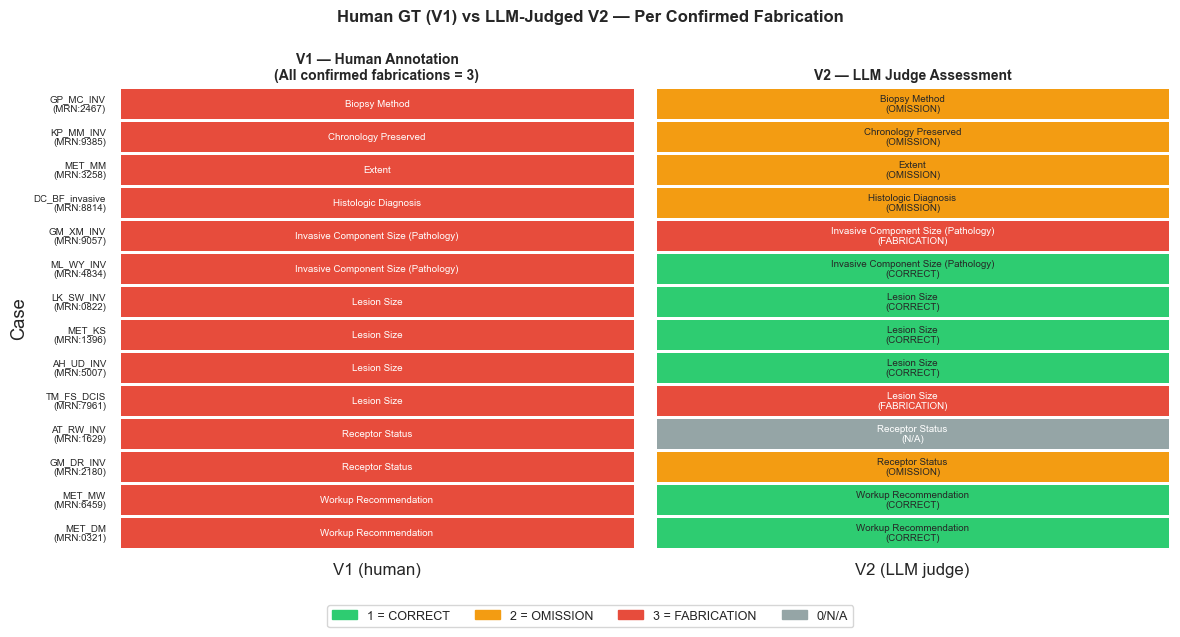

Saved: C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\reports\fab_human_gt_v2_heatmap.png


In [7]:
# --- Figure 2: Per-feature heatmap (V1=always 3 | V2=llm judge code) ---
# Sort by feature
plot_df = res_df.sort_values('feature').copy()
plot_df['case_label'] = plot_df['case_folder'] + '\n(MRN:' + plot_df['mrn'].astype(str).str[-4:] + ')'

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# V1 heatmap: all 3s (red)
ax = axes2[0]
v1_mat = pd.DataFrame(
    {'V1 (human)': [3] * len(plot_df)},
    index=plot_df['case_label']
)
sns.heatmap(
    v1_mat, ax=ax,
    cmap=['#2ecc71', '#f39c12', '#e74c3c'],
    vmin=1, vmax=3,
    linewidths=0.8, linecolor='white', cbar=False,
    annot=pd.DataFrame({'V1 (human)': plot_df['feature_display'].values},
                       index=plot_df['case_label'].values),
    fmt='', annot_kws={'fontsize': 7},
)
ax.set_title('V1 — Human Annotation\n(All confirmed fabrications = 3)', fontweight='bold', fontsize=10)
ax.set_ylabel('Case')
ax.tick_params(axis='y', labelsize=7)

# V2 heatmap: LLM judge codes
ax = axes2[1]
def to_num(c):
    try: return int(c)
    except: return 0

v2_mat = pd.DataFrame(
    {'V2 (LLM judge)': plot_df['v2_llm_code'].apply(to_num).values},
    index=plot_df['case_label'].values
)
v2_annot = pd.DataFrame(
    {'V2 (LLM judge)': plot_df.apply(
        lambda r: f"{r['feature_display']}\n({r['v2_label']})", axis=1).values},
    index=plot_df['case_label'].values
)
sns.heatmap(
    v2_mat, ax=ax,
    cmap=['#95a5a6', '#2ecc71', '#f39c12', '#e74c3c'],
    vmin=0, vmax=3,
    linewidths=0.8, linecolor='white', cbar=False,
    annot=v2_annot, fmt='', annot_kws={'fontsize': 7},
)
ax.set_title('V2 — LLM Judge Assessment', fontweight='bold', fontsize=10)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=7)

# Legend
patches = [
    mpatches.Patch(color='#2ecc71', label='1 = CORRECT'),
    mpatches.Patch(color='#f39c12', label='2 = OMISSION'),
    mpatches.Patch(color='#e74c3c', label='3 = FABRICATION'),
    mpatches.Patch(color='#95a5a6', label='0/N/A'),
]
fig2.legend(handles=patches, loc='lower center', ncol=4,
            fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.06))
plt.suptitle('Human GT (V1) vs LLM-Judged V2 — Per Confirmed Fabrication',
             fontsize=12, fontweight='bold')
plt.tight_layout()
p2 = REPORTS_DIR / 'fab_human_gt_v2_heatmap.png'
plt.savefig(p2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p2}')

In [8]:
# Save final Excel sheet
excel_path = DEEPEVAL_OUT / 'human_gt_v2_correction_sheet.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    res_df.drop(columns=['v2_reasoning']).to_excel(writer, sheet_name='Results', index=False)
    res_df[['mrn','case_folder','feature_display','v1_human_code',
            'v2_llm_code','v2_label','corrected','v2_confidence',
            'v2_reasoning']].to_excel(writer, sheet_name='Full_Results', index=False)
    pd.DataFrame([{
        'metric': 'Total human-confirmed V1 fabrications', 'value': n_total,
    },{
        'metric': 'V2 CORRECT (code 1)', 'value': n_correct,
    },{
        'metric': 'V2 OMISSION (code 2)', 'value': n_omit,
    },{
        'metric': 'V2 FABRICATION (code 3)', 'value': n_v2fab,
    },{
        'metric': 'Not fabricated in V2 (1+2+NA)', 'value': n_corrected,
    },{
        'metric': 'Correction rate (not fab in V2)', 'value': f'{100*n_corrected/max(n_total,1):.1f}%',
    }]).to_excel(writer, sheet_name='Summary', index=False)

print(f'Results saved: {excel_path}')
print()
print('=' * 55)
print('SUMMARY — Human GT V1 Fabrications vs V2')
print('=' * 55)
print(f'  Confirmed V1 fabrications (human): {n_total}/14')
print(f'  V2 correct        (code 1): {n_correct}/{n_total}')
print(f'  V2 omission       (code 2): {n_omit}/{n_total}')
print(f'  V2 still fab      (code 3): {n_v2fab}/{n_total}')
print(f'  Not fabricated in V2       : {n_corrected}/{n_total} ({100*n_corrected/max(n_total,1):.0f}%)')

Results saved: C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\data\processed\deepeval_runs\fab_v1_v2\human_gt_v2_correction_sheet.xlsx

SUMMARY — Human GT V1 Fabrications vs V2
  Confirmed V1 fabrications (human): 14/14
  V2 correct        (code 1): 6/14
  V2 omission       (code 2): 5/14
  V2 still fab      (code 3): 2/14
  Not fabricated in V2       : 12/14 (86%)
